In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import tqdm
import sys

sys.path.insert(0, '..')
from functions.IPAscoring import get_ranked_pairs
import functions.myfunctions as mf

In [ ]:
f2 = '../data/output/figures/'

In [3]:
vdj = pd.read_csv('../data/vdj_cleaned_subset_for_MI_no-small-study.csv', index_col = 0)
vdj = vdj.loc[vdj['Epitope'] != 'KLGGALQAK'] # because too big - takes forever
vdj = mf.prepare_data(vdj, col1 = 'cdr3a_IMGTgaps', col2='cdr3b_IMGTgaps', type = 'cdr3')
print(vdj.shape)

(9713, 37)


In [4]:
vdj = vdj.replace('https://www.10xgenomics.com/resources/application-notes/a-new-way-of-exploring-immunity-linking-highly-multiplexed-antigen-recognition-to-immune-repertoire-and-phenotype/#', '10xGenomics')
vdj = vdj.replace('https://github.com/antigenomics/vdjdb-db/issues/*', 'GitHubIssue', regex=True)
subject_id = mf.read_json_column(vdj, 'Meta', 'subject.id').tolist()
vdj['subject_id'] = subject_id
vdj['subject-PMID'] = vdj['Reference'].replace(pd.NA, 'unknown') + '_' + vdj['subject_id'].replace(pd.NA, 'unknown')
vdj = vdj.sort_values(by = ['Epitope', 'subject-PMID'])

In [5]:
correct_pairs = {}

for ep in vdj['Epitope'].unique():
    epdf = vdj.loc[vdj['Epitope'] == ep]
    correct_pairs[ep] = (epdf['CDR3-a'] + '::' + epdf['CDR3-b'] + '::' + epdf['subject-PMID']).tolist()

In [ ]:
tulip_pred = []

for ep in vdj['Epitope'].unique():
    ep_res = pd.read_csv('../data/output/benchmarking/TULIP/' + ep + '.csv', index_col = 0)
    tulip_pred.append(ep_res)

In [7]:
tulip_pred = pd.concat(tulip_pred)
tulip_pred.head()

,CDR3a,CDR3b,peptide,score,rank
0,CAMRANSGTYQRF,CASSGGGNTGQLYF,ASNENMETM,-0.020695,1342
1,CARGYGSSGNKLIF,CASRDWESSYEQYF,ASNENMETM,-1.190556,178
2,CAMRVSSNYQLIW,CASRGGANTGQLYF,ASNENMETM,-0.018821,1366
3,CAMREGNTGKLTF,CASRGGANTGQLYF,ASNENMETM,-0.018533,1371
4,CAMRWNSGTYQRF,CASSGGANTGQLYF,ASNENMETM,-0.010361,1521


In [8]:
correct_pairs

{'ASNENMETM': ['CAMRANSGTYQRF::CASSGGGNTGQLYF::PMID:28636592_PDValx31BALpriM1',
  'CAMREGNTGKLTF::CASRGGANTGQLYF::PMID:28636592_PDValx31BALpriM1',
  'CAMRVSSNYQLIW::CASRGGANTGQLYF::PMID:28636592_PDValx31BALpriM1',
  'CARGYGSSGNKLIF::CASRDWESSYEQYF::PMID:28636592_PDValx31BALpriM1',
  'CAMRGGGGSNAKLTF::CASSGGANTGQLYF::PMID:28636592_PDValx31BALpriM2',
  'CAMRWNSGTYQRF::CASSGGANTGQLYF::PMID:28636592_PDValx31BALpriM2',
  'CAVRHNSGGSNAKLTF::CASSQARNTEVFF::PMID:28636592_PDValx31BALpriM2',
  'CAAPPTNAYKVIF::CASSQERGSAETLYF::PMID:28636592_PDValx31BALpriM3',
  'CAMRGPYGSSGNKLIF::CASKGGGNTGQLYF::PMID:28636592_PDValx31BALpriM3',
  'CALRNNNNAPRF::CGARDGGGEQYF::PMID:28636592_mouse_subject0004',
  'CAMERSGGNYKPTF::CAWSHTGGARNTLYF::PMID:28636592_mouse_subject0004',
  'CAMRDQGGRALIF::CASSGGANTGQLYF::PMID:28636592_mouse_subject0004',
  'CAMREALGEGGRALIF::CASSGGGNTGQLYF::PMID:28636592_mouse_subject0004',
  'CAMREGKGGGSNYKLTF::CASSQDLGGTYEQYF::PMID:28636592_mouse_subject0004',
  'CAMRGSGGSNAKLTF::CASSGGSN

In [9]:
tulip_pred = tulip_pred.rename(columns={'CDR3a':'CDR3-a', 'CDR3b':'CDR3-b', 'peptide':'Epitope'})

In [10]:
tulip_pred

,CDR3-a,CDR3-b,Epitope,score,rank
0,CAMRANSGTYQRF,CASSGGGNTGQLYF,ASNENMETM,-0.020695,1342
1,CARGYGSSGNKLIF,CASRDWESSYEQYF,ASNENMETM,-1.190556,178
2,CAMRVSSNYQLIW,CASRGGANTGQLYF,ASNENMETM,-0.018821,1366
3,CAMREGNTGKLTF,CASRGGANTGQLYF,ASNENMETM,-0.018533,1371
4,CAMRWNSGTYQRF,CASSGGANTGQLYF,ASNENMETM,-0.010361,1521
...,...,...,...,...,...
38387,CAVNMLLGGGADGLTF,CASQDINTGELFF,YLQPRTFLL,-0.002489,29068
38388,CAVNMLLGGGADGLTF,CATTDLDSGELFF,YLQPRTFLL,-0.248287,15881
38389,CAVNMLLGGGADGLTF,CATQNLNTGELFF,YLQPRTFLL,-0.001249,34085
38390,CAVNMLLGGGADGLTF,CASSPTGGGNTGELFF,YLQPRTFLL,-0.055796,17481


In [11]:
assigned_pairs = {}

for ep in vdj['Epitope'].unique():
    print(ep)
    epdf_og = vdj.loc[vdj['Epitope'] == ep]
    epdf_og = epdf_og.sort_values(by = 'subject-PMID')
    epdf = tulip_pred.loc[tulip_pred['Epitope'] == ep]

    scores_mx = pd.DataFrame(np.nan,
                             index = pd.MultiIndex.from_arrays([epdf_og['subject-PMID'], epdf_og['CDR3-a'].astype(str),]),
                             columns = pd.MultiIndex.from_arrays([epdf_og['subject-PMID'], epdf_og['CDR3-b'].astype(str)]))
    alpha_seqs = [i[1] for i in scores_mx.index]
    beta_seqs = [i[1] for i in scores_mx.columns]

    assert scores_mx.shape[0] == scores_mx.shape[1] == epdf_og.shape[0]
    
    for i in tqdm.tqdm(range(epdf.shape[0])):
        row = epdf.iloc[i]
        a, b, s = row['CDR3-a'], row['CDR3-b'], row['score'].astype(float)
        scores_mx.loc[(slice(None), a), (slice(None), b)] = s
    
    scores_mx = -1*scores_mx.values

    IDs = epdf_og['subject-PMID'].tolist()
    assert len(IDs) == scores_mx.shape[0] == scores_mx.shape[1]

    mask = np.array([[int(IDs[i] != IDs[j]) for j in range(len(IDs))] for i in range(len(IDs))], dtype=bool)
    scores_mx[mask] = np.nan

    ranked_pairs = get_ranked_pairs(scores_mx, [IDs,IDs])

    assigned_pairs[ep] = [alpha_seqs[a]+'::'+beta_seqs[b]+'::'+ind for a,b,ind in ranked_pairs]

ASNENMETM


100%|██████████| 1580/1580 [00:01<00:00, 1373.16it/s]
/Users/milighm/Desktop/github-clones/AB-interactions/pairing_prediction_other_software/../functions/IPAscoring.py:156: UserWarning: Tie detected! Picking a random pair
  warn('Tie detected! Picking a random pair')


ATDALMTGF


100%|██████████| 10989/10989 [00:04<00:00, 2591.28it/s]
/Users/milighm/Desktop/github-clones/AB-interactions/pairing_prediction_other_software/../functions/IPAscoring.py:156: UserWarning: Tie detected! Picking a random pair
  warn('Tie detected! Picking a random pair')


AVFDRKSDAK


...

100%|██████████| 1324/1324 [00:00<00:00, 2506.95it/s]
/Users/milighm/Desktop/github-clones/AB-interactions/pairing_prediction_other_software/../functions/IPAscoring.py:156: UserWarning: Tie detected! Picking a random pair
  warn('Tie detected! Picking a random pair')


TTDPSFLGRY


100%|██████████| 53592/53592 [00:20<00:00, 2609.73it/s]
/Users/milighm/Desktop/github-clones/AB-interactions/pairing_prediction_other_software/../functions/IPAscoring.py:156: UserWarning: Tie detected! Picking a random pair
  warn('Tie detected! Picking a random pair')


YLQPRTFLL


100%|██████████| 38392/38392 [00:15<00:00, 2451.33it/s]
/Users/milighm/Desktop/github-clones/AB-interactions/pairing_prediction_other_software/../functions/IPAscoring.py:156: UserWarning: Tie detected! Picking a random pair
  warn('Tie detected! Picking a random pair')


In [12]:
tulip_results = pd.DataFrame()
for ep in vdj['Epitope'].unique():
    correct = correct_pairs[ep]
    predicted = assigned_pairs[ep]
    correctly_predicted = [p in correct for p in predicted]
    tot = len(correct)
    print(ep, 'Precision: ', sum(correctly_predicted) / tot)
    tulip_results.loc[ep, 'prop_correct'] = sum(correctly_predicted) / tot

ASNENMETM Precision:  0.30612244897959184
ATDALMTGF Precision:  0.016
AVFDRKSDAK Precision:  0.011771630370806356
CINGVCWTV Precision:  0.035398230088495575
ELAGIGILTV Precision:  0.0213903743315508
GILGFVFTL Precision:  0.07231516459794927
GLCTLVAML Precision:  0.12280701754385964
HGIRNASFI Precision:  0.04526748971193416
IVTDFSVIK Precision:  0.21022727272727273
KSKRTPMGF Precision:  0.030612244897959183
LLWNGPMAV Precision:  0.01276595744680851
LSLRNPILV Precision:  0.15748031496062992
LTDEMIAQY Precision:  0.016129032258064516
NLVPMVATV Precision:  0.20402298850574713
RAKFKQLL Precision:  0.13583333333333333
RLRAEAQVK Precision:  0.021844660194174758
SPRWYFYYL Precision:  0.03428571428571429
SSLENFRAYV Precision:  0.06017191977077364
SSPPMFRV Precision:  0.3082706766917293
SSYRRPVGI Precision:  0.23163841807909605
TTDPSFLGRY Precision:  0.0
YLQPRTFLL Precision:  0.03323262839879154


In [ ]:
tulip_results.to_csv('../data/output/benchmarking/TULIP_results.csv')

In [14]:
eps = sorted(vdj['Epitope'].unique())

ASNENMETM 0.30612244897959184 0.4319897959183674
ATDALMTGF 0.016 0.029440000000000004
AVFDRKSDAK 0.011771630370806356 0.016882857142857102
CINGVCWTV 0.035398230088495575 0.0439823008849557
ELAGIGILTV 0.0213903743315508 0.023475935828876974
GILGFVFTL 0.07231516459794927 0.13966571428571425
GLCTLVAML 0.12280701754385964 0.256812865497076
HGIRNASFI 0.04526748971193416 0.11526748971193414
IVTDFSVIK 0.21022727272727273 0.2250568181818181
KSKRTPMGF 0.030612244897959183 0.053877551020408136
LLWNGPMAV 0.01276595744680851 0.02097872340425527
LSLRNPILV 0.15748031496062992 0.29086614173228337
LTDEMIAQY 0.016129032258064516 0.04983870967741929
NLVPMVATV 0.20402298850574713 0.225919540229885
RAKFKQLL 0.13583333333333333 0.09713714285714281
RLRAEAQVK 0.021844660194174758 0.013495145631067913
SPRWYFYYL 0.03428571428571429 0.06359999999999996
SSLENFRAYV 0.06017191977077364 0.1455014326647564
SSPPMFRV 0.3082706766917293 0.4482706766917292
SSYRRPVGI 0.23163841807909605 0.2794915254237288
TTDPSFLGRY 0.0 

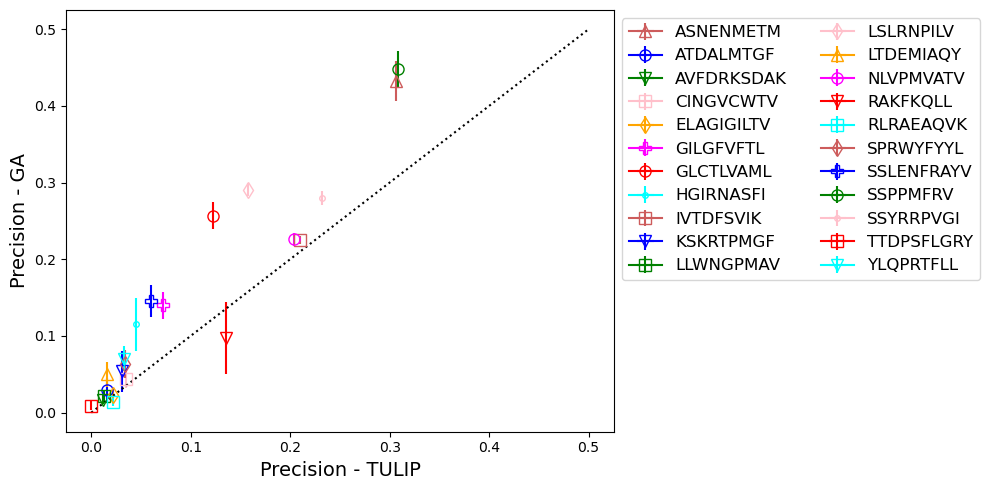

In [15]:
ga = pd.read_csv('../GA_results_TPR.csv', index_col=0)
ga['Epitope'] = [x.split('_')[0] for x in ga['epitope']]

f, ax = plt.subplots(figsize = (10,5))
symbols = ['^', 'o', 'v', 's', 'd', 'P','o','.','s','v', 's', 'd','^', 'o', 'v', 's', 'd', 'P','o','.','s','v']
colors = ['indianred','blue','g','pink','orange','fuchsia','red','cyan',
          'indianred','blue','g','pink','orange','fuchsia','red','cyan',
          'indianred','blue','g','pink', 'red','cyan']

for i, ep in enumerate(eps):
    y = np.mean(ga.loc[ga['Epitope'] == ep]['prop_correct'])
    y_err = np.std(ga.loc[ga['Epitope'] == ep]['prop_correct'])
    x = tulip_results.loc[ep]['prop_correct']
    print(ep, x,y)

    ax.errorbar(x, y, label = ep, yerr = y_err, xerr = 0, 
                marker = symbols[i], ms = 8, markerfacecolor='None', color=colors[i])

ax.plot([0,.5],[0,.5], c='k', ls=':')
ax.set_xlabel('Precision - TULIP', fontsize=14)
ax.set_ylabel('Precision - GA', fontsize=14)
plt.legend(bbox_to_anchor = [1,1], ncols=2, fontsize=12)
plt.tight_layout()
plt.savefig(f2 + 'TULIP_vs_GA.pdf', bbox_inches = 'tight')
plt.show()

ASNENMETM 0.30612244897959184 0.38571428571428573
ATDALMTGF 0.016 0.015200000000000002
AVFDRKSDAK 0.011771630370806356 0.012999999999999956
CINGVCWTV 0.035398230088495575 0.0292035398230088
ELAGIGILTV 0.0213903743315508 0.02032085561497324
GILGFVFTL 0.07231516459794927 0.11328571428571424
GLCTLVAML 0.12280701754385964 0.18274853801169588
HGIRNASFI 0.04526748971193416 0.11193415637860078
IVTDFSVIK 0.21022727272727273 0.23707386363636362
KSKRTPMGF 0.030612244897959183 0.0244897959183673
LLWNGPMAV 0.01276595744680851 0.01914893617021273
LSLRNPILV 0.15748031496062992 0.1779527559055118
LTDEMIAQY 0.016129032258064516 0.02096774193548383
NLVPMVATV 0.20402298850574713 0.21465517241379306
RAKFKQLL 0.13583333333333333 0.08339999999999996
RLRAEAQVK 0.021844660194174758 0.00849514563106792
SPRWYFYYL 0.03428571428571429 0.06628571428571423
SSLENFRAYV 0.06017191977077364 0.08968481375358162
SSPPMFRV 0.3082706766917293 0.4127819548872179
SSYRRPVGI 0.23163841807909605 0.25819209039548024
TTDPSFLGRY 0

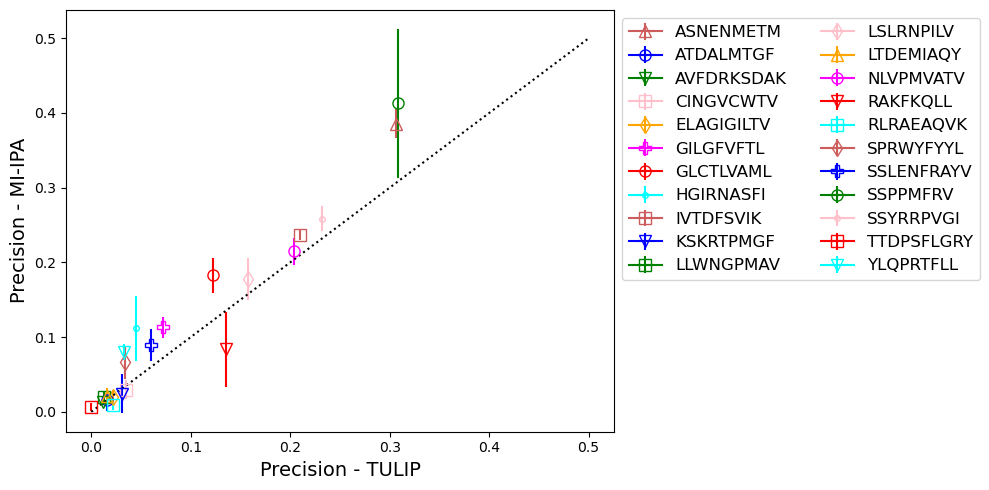

In [16]:
miipa = pd.read_csv('../MI-IPA_results_TPR.csv', index_col=0)
miipa = miipa.loc[miipa['L'] == 0.6]
miipa['Epitope'] = [x.split('_')[0] for x in miipa['epitope']]

f, ax = plt.subplots(figsize = (10,5))

for i, ep in enumerate(eps):
    y = np.mean(miipa.loc[miipa['Epitope'] == ep]['final_test_prop'])
    y_err = np.std(miipa.loc[miipa['Epitope'] == ep]['final_test_prop'])
    x = tulip_results.loc[ep]['prop_correct']
    print(ep, x,y)

    ax.errorbar(x, y, label = ep, yerr = y_err, xerr = 0, 
                marker = symbols[i], ms = 8, markerfacecolor='None', color=colors[i])

ax.plot([0,.5],[0,.5], c='k', ls=':')
ax.set_xlabel('Precision - TULIP', fontsize=14)
ax.set_ylabel('Precision - MI-IPA', fontsize=14)
plt.legend(bbox_to_anchor = [1,1], ncols=2, fontsize=12)
plt.tight_layout()
plt.savefig(f2 + 'TULIP_vs_MIIPA.pdf', bbox_inches = 'tight')
plt.show()

ASNENMETM 0.30612244897959184 0.4285714285714285
ATDALMTGF 0.016 0.019200000000000002
AVFDRKSDAK 0.011771630370806356 0.016114285714285678
CINGVCWTV 0.035398230088495575 0.02389380530973446
ELAGIGILTV 0.0213903743315508 0.025133689839572176
GILGFVFTL 0.07231516459794927 0.11859999999999998
GLCTLVAML 0.12280701754385964 0.1929824561403508
HGIRNASFI 0.04526748971193416 0.16213991769547326
IVTDFSVIK 0.21022727272727273 0.2428977272727272
KSKRTPMGF 0.030612244897959183 0.06224489795918361
LLWNGPMAV 0.01276595744680851 0.01872340425531911
LSLRNPILV 0.15748031496062992 0.2677165354330709
LTDEMIAQY 0.016129032258064516 0.05403225806451607
NLVPMVATV 0.20402298850574713 0.2327586206896551
RAKFKQLL 0.13583333333333333 0.07491428571428568
RLRAEAQVK 0.021844660194174758 0.011165048543689302
SPRWYFYYL 0.03428571428571429 0.07999999999999999
SSLENFRAYV 0.06017191977077364 0.1286532951289398
SSPPMFRV 0.3082706766917293 0.4511278195488721
SSYRRPVGI 0.23163841807909605 0.2655367231638418
TTDPSFLGRY 0.0

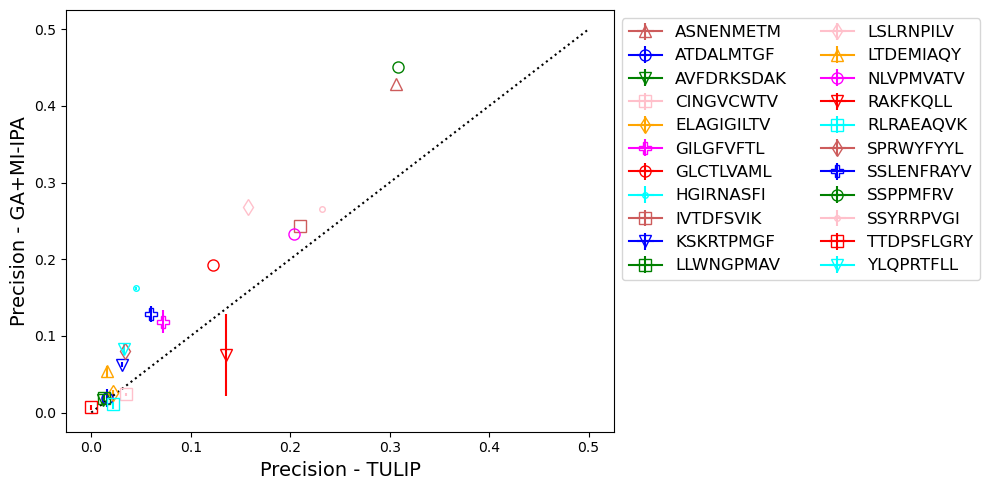

In [17]:
gami = pd.read_csv('../GA+MI-IPA_results_TPR.csv', index_col=0)
gami = gami.loc[gami['L'] == 0.6]
gami['Epitope'] = [x.split('_')[0] for x in gami['epitope']]

f, ax = plt.subplots(figsize = (10,5))

for i, ep in enumerate(eps):
    y = np.mean(gami.loc[gami['Epitope'] == ep]['final_test_prop'])
    y_err = np.std(gami.loc[gami['Epitope'] == ep]['final_test_prop'])
    x = tulip_results.loc[ep]['prop_correct']
    print(ep, x,y)

    ax.errorbar(x, y, label = ep, yerr = y_err, xerr = 0, 
                marker = symbols[i], ms = 8, markerfacecolor='None', color=colors[i])

ax.plot([0,.5],[0,.5], c='k', ls=':')
ax.set_xlabel('Precision - TULIP', fontsize=14)
ax.set_ylabel('Precision - GA+MI-IPA', fontsize=14)
plt.legend(bbox_to_anchor = [1,1], ncols=2, fontsize=12)
plt.tight_layout()
plt.savefig(f2 + 'TULIP_vs_GAMI.pdf', bbox_inches = 'tight')
plt.show()

ASNENMETM 0.30612244897959184 0.2204081632653061
ATDALMTGF 0.016 0.020800000000000003
AVFDRKSDAK 0.011771630370806356 0.011885714285714248
CINGVCWTV 0.035398230088495575 0.036725663716814114
ELAGIGILTV 0.0213903743315508 0.028609625668449157
GILGFVFTL 0.07231516459794927 0.09102857142857138
GLCTLVAML 0.12280701754385964 0.10672514619883038
HGIRNASFI 0.04526748971193416 0.05720164609053494
IVTDFSVIK 0.21022727272727273 0.22784090909090904
KSKRTPMGF 0.030612244897959183 0.017346938775510155
LLWNGPMAV 0.01276595744680851 0.01234042553191486
LSLRNPILV 0.15748031496062992 0.11811023622047241
LTDEMIAQY 0.016129032258064516 0.01612903225806448
NLVPMVATV 0.20402298850574713 0.15603448275862064
RAKFKQLL 0.13583333333333333 0.08045714285714281
RLRAEAQVK 0.021844660194174758 0.01165048543689316
SPRWYFYYL 0.03428571428571429 0.057142857142857106
SSLENFRAYV 0.06017191977077364 0.06275071633237819
SSPPMFRV 0.3082706766917293 0.23684210526315783
SSYRRPVGI 0.23163841807909605 0.21016949152542366
TTDPS

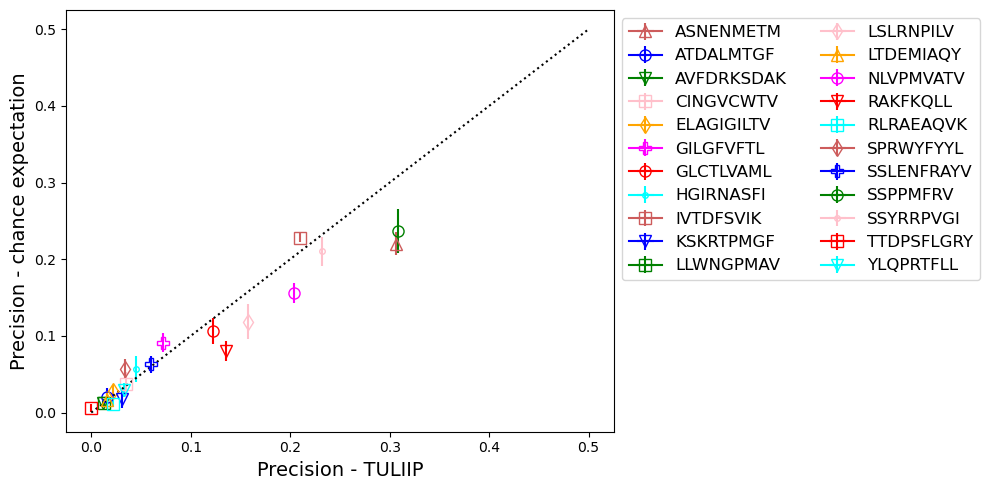

In [18]:
miipa = pd.read_csv('../MI-IPA_results_TPR.csv', index_col=0)
miipa = miipa.loc[miipa['L'] == 1]
miipa['Epitope'] = [x.split('_')[0] for x in miipa['epitope']]

f, ax = plt.subplots(figsize = (10,5))

for i, ep in enumerate(eps):
    y = np.mean(miipa.loc[miipa['Epitope'] == ep]['final_test_prop'])
    y_err = np.std(miipa.loc[miipa['Epitope'] == ep]['final_test_prop'])
    x = tulip_results.loc[ep]['prop_correct']
    print(ep, x,y)

    ax.errorbar(x, y, label = ep, yerr = y_err, xerr = 0, 
                marker = symbols[i], ms = 8, markerfacecolor='None', color=colors[i])

ax.plot([0,.5],[0,.5], c='k', ls=':')
ax.set_xlabel('Precision - TULIIP', fontsize=14)
ax.set_ylabel('Precision - chance expectation', fontsize=14)
plt.legend(bbox_to_anchor = [1,1], ncols=2, fontsize=12)
plt.tight_layout()
plt.savefig(f2 + 'TULIP_vs_MIIPA_L1.pdf', bbox_inches = 'tight')
plt.show()